In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("../data/cancer_data.csv")
X = data.copy()
X.shape

(748, 20)

In [3]:
X = X.dropna(axis = 1, thresh=int(0.5*len(X)))

In [26]:
X.columns

Index(['Gene Symbol', 'Name', 'Entrez GeneId', 'Genome Location', 'Tier',
       'Chr Band', 'Somatic', 'Tumour Types(Somatic)', 'Tissue Type',
       'Molecular Genetics', 'Mutation Types', 'Synonyms'],
      dtype='object')

In [5]:
X.dropna(subset=['Role in Cancer'], inplace=True)

In [6]:
y = X.pop("Role in Cancer")

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.33)

In [8]:
X.select_dtypes("object").columns

Index(['Gene Symbol', 'Name', 'Genome Location', 'Chr Band', 'Somatic',
       'Tumour Types(Somatic)', 'Tissue Type', 'Molecular Genetics',
       'Mutation Types', 'Synonyms'],
      dtype='object')

In [9]:
X.select_dtypes("number").columns

Index(['Entrez GeneId', 'Tier'], dtype='object')

In [10]:
X.select_dtypes(exclude=["number"]).fillna("unknown", inplace=True)
X.select_dtypes(exclude=["object"]).fillna(0, inplace=True)

In [11]:
X.select_dtypes(include="object").columns

Index(['Gene Symbol', 'Name', 'Genome Location', 'Chr Band', 'Somatic',
       'Tumour Types(Somatic)', 'Tissue Type', 'Molecular Genetics',
       'Mutation Types', 'Synonyms'],
      dtype='object')

In [12]:
from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value= -1)

X_train=ord.fit_transform(X_train)
X_test=ord.transform(X_test)

In [13]:
y_train=ord.fit_transform(pd.DataFrame(y_train))
y_test=ord.transform(pd.DataFrame(y_test))

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns


<Axes: >

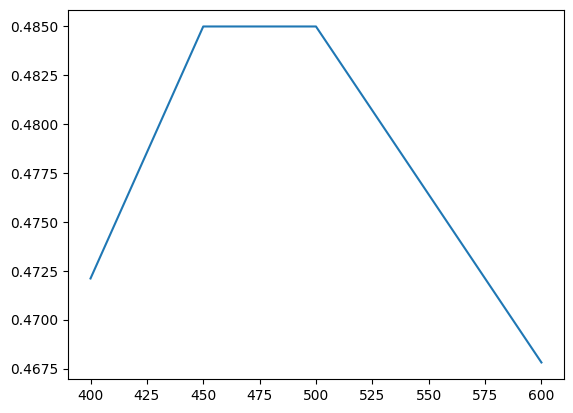

In [22]:
estms = [400, 450, 500, 550,600]
acc_score = []
for est in estms:
    model = XGBClassifier(device = 'cuda', n_estimators = est, learning_rate = 0.03)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc_score.append(accuracy_score(y_test, preds))

sns.lineplot(x=estms, y=acc_score)

<Axes: >

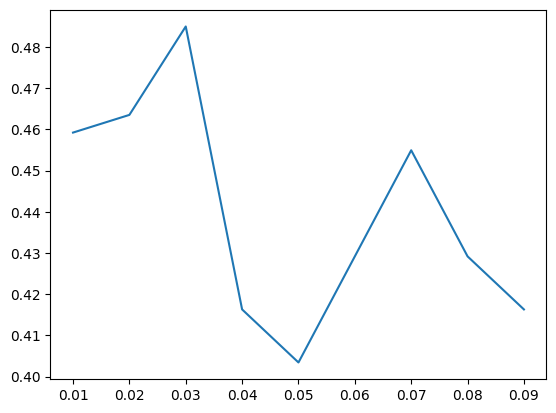

In [23]:
rates = [0.01, 0.02, 0.03, 0.04,0.05, 0.06, 0.07, 0.08, 0.09]
acc_score = []
for rate in rates:
    model = XGBClassifier(device = 'cuda', n_estimators = 475, learning_rate = rate)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc_score.append(accuracy_score(y_test, preds))

sns.lineplot(x=rates, y=acc_score)

In [24]:
final_model = XGBClassifier(device = 'cuda', n_estimators = 475, learning_rate = 0.03)

final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

accuracy_score(y_test, final_pred)

0.48497854077253216